In [9]:
import mne
from mne.io import read_raw_fieldtrip
from mnelab.io.readers import read_raw
from numpy.core.records import fromarrays
from scipy.io import savemat
from pyxdf import resolve_streams
from PyQt5.QtWidgets import QFileDialog, QMessageBox, QDialog, QVBoxLayout, QListWidget, QPushButton, QHBoxLayout
import numpy as np
import pandas as pd
import pickle
from copy import deepcopy
from os.path import basename, dirname, join
import json
from collections import defaultdict
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

from functions.tmsi_poly5reader import Poly5Reader
import functions.utils
from pyxdftools.xdfdata import XdfData

C:\Users\Juliette\AppData\Local\Temp\ipykernel_10248\509486344.py:4: DeprecationWarning: numpy.core.records is deprecated and has been renamed to numpy._core.records. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.records.fromarrays.
  from numpy.core.records import fromarrays


In [3]:
file_name = r"C:\Users\Juliette\Downloads\Report_Json_Session_Report_20250528T165104.json"

with open(file_name, 'r') as f:
    j = json.loads(f.read())     

In [28]:
list_of_is = j['IndefiniteStreaming']
len(list_of_is)

12

In [37]:
list_of_is[0]

{'Pass': '',
 'GlobalSequences': '0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20

In [40]:
stored_first_packet_times = []
stored_ch_names = []
for i in range(len(list_of_is)):
    # print(list_of_is[i]['FirstPacketDateTime'])
    stored_first_packet_times.append(list_of_is[i]['FirstPacketDateTime'])
    stored_ch_names.append(list_of_is[i]['Channel'])

print(f'Unique first packet times: {np.unique(stored_first_packet_times)}')


Unique first packet times: ['2025-05-28T13:49:09.000Z' '2025-05-28T13:50:09.000Z']


In [41]:
stored_ch_names


['ZERO_THREE_LEFT',
 'ONE_THREE_LEFT',
 'ZERO_TWO_LEFT',
 'ZERO_THREE_RIGHT',
 'ONE_THREE_RIGHT',
 'ZERO_TWO_RIGHT',
 'ZERO_THREE_LEFT',
 'ONE_THREE_LEFT',
 'ZERO_TWO_LEFT',
 'ZERO_THREE_RIGHT',
 'ONE_THREE_RIGHT',
 'ZERO_TWO_RIGHT']

In [11]:
%matplotlib qt
plt.plot(list_of_is[0]['TicksInMses'])

In [12]:
list_of_is[0]['TicksInMses']

'980700,980700,980700,980950,980950,981200,981200,981450,981450,981700,981700,981950,981950,982200,982200,982450,982450,982700,982700,982950,982950,983200,983200,983450,983450,983700,983700,983950,983950,984200,984200,984450,984450,984700,984700,984950,984950,985200,985200,985450,985450,985700,985700,985950,985950,986200,986200,986450,986450,986700,986700,986950,986950,987200,987200,987450,987450,987700,987700,987950,987950,988200,988200,988450,988450,988700,988700,988950,988950,989200,989200,989450,989450,989700,989700,989950,989950,990200,990200,990450,990450,990700,990700,990950,990950,991200,991200,991450,991450,991700,991700,991950,991950,992200,992200,992450,992450,992700,992700,992950,992950,993200,993200,993450,993450,993700,993700,993950,993950,994200,994200,994450,994450,994700,994700,994950,994950,995200,995200,995450,995450,995700,995700,995950,995950,996200,996200,996450,996450,996700,996700,996950,996950,997200,997200,997450,997450,997700,997700,997950,997950,998200,99820

In [13]:
def convert_list_string_floats(
    string_list
):
    """
    Copied from jgvhabets pyPerceive repository.
    """
    try:
        floats = [float(v) for v in string_list.split(',')]
    except:
        floats = [float(v) for v in string_list[:-1].split(',')]

    return floats


In [19]:
ticks_0 = convert_list_string_floats(list_of_is[0]['TicksInMses'])
packet_sizes_0 = convert_list_string_floats(list_of_is[0]['GlobalPacketSizes'])
ch_0 = list_of_is[0]['TimeDomainData']

ticks_1 = convert_list_string_floats(list_of_is[1]['TicksInMses'])
packet_sizes_1 = convert_list_string_floats(list_of_is[1]['GlobalPacketSizes'])
ch_1 = list_of_is[1]['TimeDomainData']



In [21]:
plt.plot(ch_0)
plt.plot(ch_1)

In [22]:
plt.plot(ticks_0)
plt.plot(ticks_1)

In [23]:
plt.plot(packet_sizes_0)
plt.plot(packet_sizes_1)

In [24]:
np.unique(packet_sizes_0)

array([24., 25., 36., 38.])

In [25]:
np.unique(packet_sizes_1)

array([24., 25., 36., 38.])

In [72]:
def check_and_correct_missing_packets(streamings_dict, BrainSenseRaws, streamings_df):
    """
    Inspired by jgvhabets pyPerceive repository check_and_correct_missings_in_lfp function.
    Detection similar but correction improved to better match the actual missing packets.
    """
    BrainSenseRawsCorrected = {}
    corrected_column = []

    for i in streamings_dict.keys():
        dat = streamings_dict[i][BrainSenseRaws[i].ch_names[0]]
        if type(dat['TicksInMses']) == str:
            ticksMsec = convert_list_string_floats(dat['TicksInMses'])
        else: 
            ticksMsec = dat['TicksInMses']
        ticksDiffs = np.diff(np.array(ticksMsec))

        data_is_missing = (ticksDiffs != 250).any()
        if type(dat['GlobalPacketSizes']) == str:
            packetSizes = convert_list_string_floats(dat['GlobalPacketSizes'])
        else:
            packetSizes = dat['GlobalPacketSizes']

        data_array = BrainSenseRaws[i].get_data()
        new_data_array = []
        metadata = BrainSenseRaws[i].info

        if data_is_missing:
            missing_indexes = np.where(ticksDiffs > 250)[0]
            print(f"Streaming {i} has missing ticks at indexes: {missing_indexes}")
            #time_missing = (ticksDiffs[missing_indexes] - 250).astype(int)
            duplicated_indexes = np.where(ticksDiffs < 250)[0] 
            duplicated_ticks_values = np.unique([int(ticksMsec[idx]) for idx in duplicated_indexes])
            print(f"Streaming {i} has duplicated ticks at indexes: {duplicated_indexes}. Duplicated ticks are {duplicated_ticks_values}.")
            # sometimes ticks are duplicated because many packets/samples were 
            # sent after a short interruption, this has to be taken into account 
            # before correcting timestamps.
            #irregular_sizes = [size for size in packetSizes if size not in [62, 63]]
            #bigger_packets_indexes = [np.where(size not in [62, 63])[0] for size in packetSizes if size not in [62, 63]]
            bigger_packets_indexes = np.where(~np.isin(packetSizes, [62, 63]))[0]
            print(f"Streaming {i} has bigger packets at indexes: {bigger_packets_indexes}. Packets are {[int(packetSizes[idx]) for idx in bigger_packets_indexes]} samples long.")


            """Here add part to handle cases where missing ticks are due to bigger packets/duplicated ticks/...
            Should start from the top (last Ticks) and go up packet by packet, always checking packet size and duplicated ticks.
            """
            reverted_ticks = ticksMsec[::-1]
            reverted_packetSizes = packetSizes[::-1]
            # create an array of nan with same size as the total number of packets
            #N = sum(packetSizes)
            #data_or_nan = np.full(N, np.nan)
            data_or_nan = []
            #current_idx_ticks = 0
            #current_idx_data_or_nan = 0

            pkt_idx = 0

            while pkt_idx < len(reverted_ticks) - 1:

                tick = int(reverted_ticks[pkt_idx])
                pkt_size = int(reverted_packetSizes[pkt_idx])

                if pkt_size not in [62, 63]:
                    print(f"Packet at index {len(reverted_ticks)-1 - pkt_idx}/{pkt_idx} has irregular size of {pkt_size} samples.")

                tick_pred = tick - (250 * round((pkt_size * 4) / 250))

                if tick_pred == int(reverted_ticks[pkt_idx + 1]):
                    #print("Predicted tick matches the next tick, no missing data, keeping all samples.")
                    data_or_nan.extend(['data'] * pkt_size)
                    pkt_idx += 1
                    continue

                else:
                    # ---------------- DUPLICATED TICK PATH  ----------------
                    if tick == int(reverted_ticks[pkt_idx + 1]):
                        print("Tick is duplicated, handling accordingly.")

                        num_duplicates = 1
                        while int(reverted_ticks[pkt_idx + 1 + num_duplicates]) == tick:
                            num_duplicates += 1

                        print(f" Num of duplicates for tick value {tick} is {num_duplicates}.")

                        total_samples_in_duplicated_ticks = 0
                        for dup_idx in range(pkt_idx, pkt_idx + 1 + num_duplicates):
                            total_samples_in_duplicated_ticks += int(reverted_packetSizes[dup_idx])
                            print(f" Adding packet of size {int(reverted_packetSizes[dup_idx])} samples.")

                        print(f"total samples : {total_samples_in_duplicated_ticks}")

                        tick_after_duplicates = int(reverted_ticks[pkt_idx + 1 + num_duplicates])
                        # double-check if previous packet also was of irregular size. If yes, then take it into account for expected tick calculation
                        previous_packet_size = reverted_packetSizes[pkt_idx - 1] if pkt_idx - 1 >= 0 else 0
                        if previous_packet_size not in [62, 63] and pkt_idx - 1 >= 0:
                            print(f"Previous packet at index {len(reverted_ticks)-1 - (pkt_idx - 1)}/{pkt_idx - 1} also has irregular size of {previous_packet_size} samples.")
                            global_extra_pkt_size = total_samples_in_duplicated_ticks + int(previous_packet_size)
                            previous_tick = int(reverted_ticks[pkt_idx - 1])
                            expected_tick_after_duplicates = previous_tick - (
                                250 * round(((global_extra_pkt_size) * 4) / 250)
                            )

                        else:
                            expected_tick_after_duplicates = tick - (
                                250 * round(((total_samples_in_duplicated_ticks) * 4) / 250)
                            )
                        print(f"Predicted next tick after duplicated ticks: {expected_tick_after_duplicates}, actual next tick: {tick_after_duplicates}")

                        if expected_tick_after_duplicates == tick_after_duplicates:
                            print(f"Duplicated tick but no loss of data detected")
                            data_or_nan.extend(['data'] * total_samples_in_duplicated_ticks)
                            pkt_idx += num_duplicates + 1 # <-- move to the next non-duplicate packet
                            print(f"Moving to packet index {pkt_idx}.")
                            continue
                        else:
                            print(f"Missing data detected after duplicated ticks")
                            data_or_nan.extend(['data'] * total_samples_in_duplicated_ticks) # add the data anyway, but complete with nans
                            # here add nan for missing data after duplicated ticks
                            missing_samples_after_duplicates = expected_tick_after_duplicates - tick_after_duplicates
                            n_missing_packets_after_duplicates = missing_samples_after_duplicates // 250
                            # determine how many 62 and 63 packets to add based on last packet size
                            if n_missing_packets_after_duplicates % 2 == 0:
                                num_62 = num_63 = n_missing_packets_after_duplicates // 2
                            else:
                                if pkt_size == 63:
                                    num_62 = (n_missing_packets_after_duplicates // 2) + 1
                                    num_63 = n_missing_packets_after_duplicates // 2
                                else:
                                    num_63 = (n_missing_packets_after_duplicates // 2) + 1
                                    num_62 = n_missing_packets_after_duplicates // 2
                            total_missing_samples_to_add = (num_62 * 62) + (num_63 * 63)
                            data_or_nan.extend(['nan'] * total_missing_samples_to_add)
                            print(f"Added {total_missing_samples_to_add} NaN samples for {n_missing_packets_after_duplicates} missing packets ")
                            pkt_idx += num_duplicates + 1  # move to the next non-duplicate packet
                            print(f"Moving to packet index {pkt_idx}.")
                            continue

                    # ---------------- MISSING TICK PATH ----------------
                    else:
                        print("Missing tick(s) detected, adding NaNs for missing data.")

                        total_missing_time = tick_pred - int(reverted_ticks[pkt_idx + 1])
                        n_missing_packets = total_missing_time // 250

                        # determine how many 62 and 63 packets to add based on last packet size
                        if n_missing_packets % 2 == 0:
                            num_62 = num_63 = n_missing_packets // 2
                        else:
                            if pkt_size == 63:
                                num_62 = (n_missing_packets // 2) + 1
                                num_63 = n_missing_packets // 2
                            else:
                                num_63 = (n_missing_packets // 2) + 1
                                num_62 = n_missing_packets // 2

                        total_samples_to_add = (num_62 * 62) + (num_63 * 63)
                        data_or_nan.extend(['nan'] * total_samples_to_add)

                        print(f"Added {total_samples_to_add} NaN samples for {n_missing_packets} missing packets "
                            f"({num_62} of 62 samples and {num_63} of 63 samples).")

                        pkt_idx += 1   # EXACTLY like you originally had
                        continue


            data_or_nan_reverted = data_or_nan[::-1]     

            # for each streaming, loop through each channel to add the missing NaNs
            for channel in range(len(data_array)):
                ch_data = data_array[channel, :]
                ch_data_idx = 0
                new_ch_arr = [] # initialize empty list
                # add ch_data values or NaNs based on data_or_nan_reverted
                for idx, item in enumerate(data_or_nan_reverted):
                    if item == 'data':
                        new_ch_arr.append(ch_data[ch_data_idx])
                        ch_data_idx += 1
                    elif item == 'nan':
                        new_ch_arr.append(np.nan)
                new_ch_arr = np.array(new_ch_arr)  # convert list to numpy array
                new_data_array.append(new_ch_arr)               

            # always remove 250 from unique diffs, as that is the normal packet distance
            unique_diff = np.unique(ticksDiffs)
            unique_diff = unique_diff[unique_diff != 250.0]

            # return how many times each missing packet length occurred
            missing_packet_lengths = np.unique(ticksDiffs[ticksDiffs != 250.0])
            missing_packet_real_lengths = missing_packet_lengths - 250  # in milliseconds
            missing_packet_counts = {length: int(np.sum(ticksDiffs == length+250)) for length in missing_packet_real_lengths}  
            corrected_or_not = f'Yes, missing packets: {missing_packet_counts}'

            raw_new = mne.io.RawArray(
                data = new_data_array,
                info = metadata
            )
            BrainSenseRawsCorrected[i] = raw_new

        else:
            corrected_or_not = 'No'
            BrainSenseRawsCorrected[i] = BrainSenseRaws[i]

        corrected_column.append(corrected_or_not)

    streamings_df_corrected = streamings_df.copy()
    print(f"Corrected column: {corrected_column}")
    print(f"Length of corrected column: {len(corrected_column)}, Length of streamings_df_corrected: {len(streamings_df_corrected)}")
    streamings_df_corrected['LFP Corrected for missing packets'] = corrected_column

    return BrainSenseRawsCorrected, streamings_df_corrected

In [111]:
# keep the first part similar to process BS streamings:
list_of_streamings = j['BrainSenseTimeDomain']
list_of_stim_streamings = j['BrainSenseLfp']

streamings_dict = defaultdict(lambda: defaultdict(dict))
    
stream_times = [0]
first_packet_time = None
stream_count = 1

for i_stream, dat in enumerate(list_of_streamings):
    print(f"Stream {i_stream} keys: {dat.keys()}")  # DEBUG
    first_packet_time = dat['FirstPacketDateTime']

    if first_packet_time != stream_times[-1] or i_stream == 0:
        # new stream
        streamings_dict[f'streaming_{stream_count}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': first_packet_time,
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'], 
            'SampleRateInHz': dat['SampleRateInHz']
        }
        stream_count += 1
    else:
        # other channel from same stream
        streamings_dict[f'streaming_{stream_count - 1}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': dat['FirstPacketDateTime'],
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'],
            'SampleRateInHz': dat['SampleRateInHz']
        }
    stream_times.append(first_packet_time)

#  create a dataframe with all streamings and their channels
ends = []
prev_streaming_id = None
stream_count = -1
#prev_stream_last_stim_ticks = None

streamings_df = pd.DataFrame(columns=[
    'Streaming id', 'LFP Channels', 'LFP Recording start', 'LFP Recording end', 
    'LFP Recording duration'
    ])
for streaming_id in streamings_dict.keys():
    stream_count += 1
    channels = []
    time_since_last_rec_first_packet = None
    time_since_last_rec_ticks = None
    for channel in streamings_dict[streaming_id].keys():
        channels.append(channel)

        ticks_in_ms = streamings_dict[streaming_id][channel]['TicksInMses']
        rec_dur_ms = ticks_in_ms[-1] - ticks_in_ms[0] + 250  # add 250 ms for last packet duration
        rec_dur_min, rec_dur_sec, rec_dur_msec = functions.utils.convert_msec_to_min_sec_msec(rec_dur_ms)
        dt_str = streamings_dict[streaming_id][channel]['FirstPacketDateTime']
        dt_obj = datetime.strptime(dt_str, '%Y-%m-%dT%H:%M:%S.%fZ')
        
        # compute rec_end_time using dt_obj + rec_duration: 
        rec_end_time = dt_obj +  timedelta(minutes=rec_dur_min, seconds=rec_dur_sec, milliseconds=rec_dur_msec)

        if ends and streaming_id == prev_streaming_id:
            time_since_last_rec = timedelta(0)
        elif ends:
            time_since_last_rec = dt_obj - ends[-1]
        else:
            time_since_last_rec = timedelta(0)

        dt1_parsed = datetime.strptime(streamings_dict[streaming_id][channel]['FirstPacketDateTime'], "%Y-%m-%dT%H:%M:%S.%fZ")
        
        # Simply output it in the same visual format as dt2
        dt1_reformatted = dt1_parsed.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # trim to .XXX milliseconds
        
        if time_since_last_rec_first_packet is None:
            time_since_last_rec_first_packet = functions.utils.format_timedelta(time_since_last_rec)
        if time_since_last_rec_ticks is None:
            if streaming_id != 'streaming_1':  # for the first streaming, we don't have a previous streaming to compare to
                channel_previous = list(streamings_dict[prev_streaming_id].keys())[0]
            else:
                channel_previous = channel    
            time_since_last_rec_ticks = functions.utils.format_timedelta(timedelta(milliseconds=(ticks_in_ms[0] - (streamings_dict[prev_streaming_id][channel_previous]['TicksInMses'][-1])) )) if ends and streaming_id != prev_streaming_id else '0 days, 0h, 0min, 0s, 0ms'
        prev_streaming_id = streaming_id
        # convert time_since_last_rec in milliseconds
        #time_since_last_rec_ticks_ms = functions.utils.time_to_ms(time_since_last_rec_ticks)
        #time_since_last_rec_first_packet_ms = functions.utils.time_to_ms(time_since_last_rec_first_packet)

        ends.append(rec_end_time)

    data = list_of_stim_streamings[stream_count]['LfpData']
    #ticks = np.array([d['TicksInMs'] for d in data])
    right_mA = np.array([d['Right']['mA'] for d in data])
    left_mA = np.array([d['Left']['mA'] for d in data])
    #time_since_last_rec_ticks_stim = (ticks[0] - 250) - prev_stream_last_stim_ticks if prev_stream_last_stim_ticks is not None else 0
    #prev_stream_last_stim_ticks = ticks[-1] 
    new_row = pd.DataFrame([{
    'Streaming id': streaming_id,
    'LFP Channels': channels,
    'LFP Recording start': dt1_reformatted,
    'LFP Recording end': rec_end_time,
    'LFP Recording duration': f'{rec_dur_min} min, {rec_dur_sec} sec, {rec_dur_msec} ms',
    'First packet time (ms)': ticks_in_ms[0],
    'Last packet time (ms)': ticks_in_ms[-1],
    }])
    streamings_df = pd.concat([streamings_df, new_row], ignore_index=True)



# create an MNE Raw object for each stream and channel, and store them in a dictionary
# First keep the part for BS streamings
BrainSenseRaws = {}

for i, stream in enumerate(streamings_dict.keys()):
    #stream_dict = {}
    ch_names = []
    stim_ch_names = []
    data_arrays = []
    raw = streamings_dict[stream]
    for ch in raw.keys(): 
        ch_data = raw[ch]['TimeDomainData']
        ch_names.append(ch)
        #data_arrays.append(ch_data)
        data_arrays.append(np.array(ch_data)) #* 1e-6)
        #side = 'Left' if 'LEFT' in ch else 'Right'
        stim_ch_names.append('STIM_' + ch)

# Because their sampling rate is different, resample them so that they match the LFP data length and crop if necessary (for small irregularities)        
    stim_sf = j['BrainSenseLfp'][i]['SampleRateInHz']  # == 2Hz
    left_stim = []
    right_stim = []
    for k in range(len(j['BrainSenseLfp'][i]['LfpData'])):
        # get right and left mA values
        right_mA = j['BrainSenseLfp'][i]['LfpData'][k]['Right']['mA']
        left_mA = j['BrainSenseLfp'][i]['LfpData'][k]['Left']['mA']
        right_stim.append(right_mA)
        left_stim.append(left_mA)        
    nb_points_stim = len(right_stim)
    stim_time = np.arange(nb_points_stim) * (1.0 / stim_sf)      # e.g. every 0.5 s          
    lfp_time  = np.arange(int(len(right_stim) * (250 / stim_sf))) / 250  # upsampled time

    # resample stim data to match lfp data length
    # Nearest-neighbor interpolation
    right_stim_resampled = np.interp(
        lfp_time,
        stim_time,
        right_stim,
        left=None,
        right=None,
    )

    left_stim_resampled = np.interp(
        lfp_time,
        stim_time,
        left_stim,
        left=None,
        right=None,
    )    

    # add some NaNs if resampled stim data is shorter than lfp data
    lfp_data_length = len(raw[ch]['TimeDomainData'])
    if len(left_stim_resampled) < lfp_data_length:
        left_stim_resampled = np.concatenate([np.nan * np.ones(lfp_data_length - len(left_stim_resampled)), left_stim_resampled])
    elif len(left_stim_resampled) > lfp_data_length:
        left_stim_resampled = left_stim_resampled[-lfp_data_length:]
    if len(right_stim_resampled) < lfp_data_length:
        right_stim_resampled = np.concatenate([np.nan * np.ones(lfp_data_length - len(right_stim_resampled)), right_stim_resampled])
    elif len(right_stim_resampled) > lfp_data_length:
        right_stim_resampled = right_stim_resampled[-lfp_data_length:]            
    left_stim_resampled_scaled = np.array(left_stim_resampled) #* 1e-6
    right_stim_resampled_scaled = np.array(right_stim_resampled) #* 1e-6
    # data_arrays.append(left_stim_resampled_scaled)
    # data_arrays.append(right_stim_resampled_scaled)
    # only keep stim channel is lfp channel present:
    if any("LEFT" in ch for ch in ch_names):
        data_arrays.append(left_stim_resampled_scaled)
    if any("RIGHT" in ch for ch in ch_names):
        data_arrays.append(right_stim_resampled_scaled)

    info = mne.create_info(
    ch_names=ch_names + stim_ch_names,
    sfreq=250,  # Percept sampling frequency is by default 250Hz
    ch_types=['eeg'] * len(ch_names) + ['eeg'] * len(stim_ch_names)
    )

    raw = mne.io.RawArray(
        data = np.array(data_arrays),
        info = info
    )
    BrainSenseRaws[stream] = raw                

# Now BrainSenseRaws contains all streams as MNE Raw objects, but we 
# still need to check for missing packets and correct them
# Loop through each stream and check for missing packets in each channel 
# based on the function check_and_correct_missing_packets()
BrainSenseRawsCorrected, streamings_df_corrected = check_and_correct_missing_packets(streamings_dict, BrainSenseRaws, streamings_df) 


# Reproduce BS streaming processing but adapt for IS and add to the existing dataframe:
list_of_is = j['IndefiniteStreaming']

is_dict = defaultdict(lambda: defaultdict(dict))
    
stream_times = [0]
first_packet_time = None
is_stream_count = 1

for i_stream, dat in enumerate(list_of_is):
    print(f"Stream {i_stream} keys: {dat.keys()}")  # DEBUG
    first_packet_time = dat['FirstPacketDateTime']

    if first_packet_time != stream_times[-1] or i_stream == 0:
        # new stream
        is_dict[f'IS_{is_stream_count}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': first_packet_time,
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'], 
            'SampleRateInHz': dat['SampleRateInHz']
        }
        is_stream_count += 1
    else:
        # other channel from same stream
        is_dict[f'IS_{is_stream_count - 1}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': dat['FirstPacketDateTime'],
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'],
            'SampleRateInHz': dat['SampleRateInHz']
        }
    stream_times.append(first_packet_time)

#  create a dataframe with all streamings and their channels
ends = []
prev_streaming_id = None
stream_count = -1
#prev_stream_last_stim_ticks = None

# is_streamings_df = pd.DataFrame(columns=[
#     'Streaming id', 'LFP Channels', 'LFP Recording start', 'LFP Recording end', 
#     'LFP Recording duration'
#     ])
for streaming_id in is_dict.keys():
    stream_count += 1
    channels = []
    time_since_last_rec_first_packet = None
    time_since_last_rec_ticks = None
    for channel in is_dict[streaming_id].keys():
        channels.append(channel)

        ticks_in_ms = is_dict[streaming_id][channel]['TicksInMses']
        rec_dur_ms = ticks_in_ms[-1] - ticks_in_ms[0] + 250  # add 250 ms for last packet duration
        rec_dur_min, rec_dur_sec, rec_dur_msec = functions.utils.convert_msec_to_min_sec_msec(rec_dur_ms)
        dt_str = is_dict[streaming_id][channel]['FirstPacketDateTime']
        dt_obj = datetime.strptime(dt_str, '%Y-%m-%dT%H:%M:%S.%fZ')
        
        # compute rec_end_time using dt_obj + rec_duration: 
        rec_end_time = dt_obj +  timedelta(minutes=rec_dur_min, seconds=rec_dur_sec, milliseconds=rec_dur_msec)

        if ends and streaming_id == prev_streaming_id:
            time_since_last_rec = timedelta(0)
        elif ends:
            time_since_last_rec = dt_obj - ends[-1]
        else:
            time_since_last_rec = timedelta(0)

        dt1_parsed = datetime.strptime(is_dict[streaming_id][channel]['FirstPacketDateTime'], "%Y-%m-%dT%H:%M:%S.%fZ")
        
        # Simply output it in the same visual format as dt2
        dt1_reformatted = dt1_parsed.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # trim to .XXX milliseconds
        
        if time_since_last_rec_first_packet is None:
            time_since_last_rec_first_packet = functions.utils.format_timedelta(time_since_last_rec)
        if time_since_last_rec_ticks is None:
            if streaming_id != 'IS_1':  # for the first streaming, we don't have a previous streaming to compare to
                channel_previous = list(is_dict[prev_streaming_id].keys())[0]
            else:
                channel_previous = channel    
            time_since_last_rec_ticks = functions.utils.format_timedelta(timedelta(milliseconds=(ticks_in_ms[0] - (is_dict[prev_streaming_id][channel_previous]['TicksInMses'][-1])) )) if ends and streaming_id != prev_streaming_id else '0 days, 0h, 0min, 0s, 0ms'
        prev_streaming_id = streaming_id
        # convert time_since_last_rec in milliseconds
        #time_since_last_rec_ticks_ms = functions.utils.time_to_ms(time_since_last_rec_ticks)
        #time_since_last_rec_first_packet_ms = functions.utils.time_to_ms(time_since_last_rec_first_packet)

        ends.append(rec_end_time)

    new_row = pd.DataFrame([{
    'Streaming id': streaming_id,
    'LFP Channels': channels,
    'LFP Recording start': dt1_reformatted,
    'LFP Recording end': rec_end_time,
    'LFP Recording duration': f'{rec_dur_min} min, {rec_dur_sec} sec, {rec_dur_msec} ms',
    'First packet time (ms)': ticks_in_ms[0],
    'Last packet time (ms)': ticks_in_ms[-1],
    }])
    streamings_df_corrected = pd.concat([streamings_df_corrected, new_row], ignore_index=True)

    

Stream 0 keys: dict_keys(['Pass', 'GlobalSequences', 'GlobalPacketSizes', 'TicksInMses', 'Channel', 'Gain', 'FirstPacketDateTime', 'FirstPacketDateTimeBlockId', 'FirstPacketDateTimeOffsetInSeconds', 'SampleRateInHz', 'TimeDomainData'])
Stream 1 keys: dict_keys(['Pass', 'GlobalSequences', 'GlobalPacketSizes', 'TicksInMses', 'Channel', 'Gain', 'FirstPacketDateTime', 'FirstPacketDateTimeBlockId', 'FirstPacketDateTimeOffsetInSeconds', 'SampleRateInHz', 'TimeDomainData'])
Stream 2 keys: dict_keys(['Pass', 'GlobalSequences', 'GlobalPacketSizes', 'TicksInMses', 'Channel', 'Gain', 'FirstPacketDateTime', 'FirstPacketDateTimeBlockId', 'FirstPacketDateTimeOffsetInSeconds', 'SampleRateInHz', 'TimeDomainData'])
Stream 3 keys: dict_keys(['Pass', 'GlobalSequences', 'GlobalPacketSizes', 'TicksInMses', 'Channel', 'Gain', 'FirstPacketDateTime', 'FirstPacketDateTimeBlockId', 'FirstPacketDateTimeOffsetInSeconds', 'SampleRateInHz', 'TimeDomainData'])
Creating RawArray with float64 data, n_channels=4, n_tim

C:\Users\Juliette\AppData\Local\Temp\ipykernel_10248\3811493261.py:107: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  streamings_df = pd.concat([streamings_df, new_row], ignore_index=True)


In [112]:
streamings_df_corrected

,Streaming id,LFP Channels,LFP Recording start,LFP Recording end,LFP Recording duration,First packet time (ms),Last packet time (ms),LFP Corrected for missing packets
0,streaming_1,"[Channel_ONE_THREE_LEFT, Channel_ONE_THREE_RIGHT]",2025-05-28 13:52:01.000,2025-05-28 13:54:09.250,"2.0 min, 8.0 sec, 250.0 ms",1127700.0,1255700.0,No
1,streaming_2,"[Channel_ONE_THREE_LEFT, Channel_ONE_THREE_RIGHT]",2025-05-28 13:54:28.000,2025-05-28 14:00:46.500,"6.0 min, 18.0 sec, 500.0 ms",1274450.0,1652700.0,No
2,IS_1,"[Channel_ZERO_THREE_LEFT, Channel_ONE_THREE_LE...",2025-05-28 13:49:09.000,2025-05-28 13:50:05.500,"0.0 min, 56.0 sec, 500.0 ms",980700.0,1036950.0,NaN
3,IS_2,"[Channel_ZERO_THREE_LEFT, Channel_ONE_THREE_LE...",2025-05-28 13:50:09.000,2025-05-28 13:51:23.500,"1.0 min, 14.0 sec, 500.0 ms",1040950.0,1115200.0,NaN


In [113]:
# Now also create MNE objects for IS streamings, but adapt the code to the IS data structure
# ISRaws = {}

for i, stream in enumerate(is_dict.keys()):
    #stream_dict = {}
    ch_names = []
    stim_ch_names = []
    data_arrays = []
    raw = is_dict[stream]
    for ch in raw.keys(): 
        ch_data = raw[ch]['TimeDomainData']
        ch_names.append(ch)
        data_arrays.append(np.array(ch_data)) #* 1e-6)

    info = mne.create_info(
    ch_names=ch_names,
    sfreq=250,  # Percept sampling frequency is by default 250Hz
    ch_types=['eeg'] * len(ch_names)
    )

    raw = mne.io.RawArray(
        data = np.array(data_arrays),
        info = info
    )
    BrainSenseRawsCorrected[stream] = raw   

Creating RawArray with float64 data, n_channels=6, n_times=14188
    Range : 0 ... 14187 =      0.000 ...    56.748 secs
Ready.
Creating RawArray with float64 data, n_channels=6, n_times=16946
    Range : 0 ... 16945 =      0.000 ...    67.780 secs
Ready.


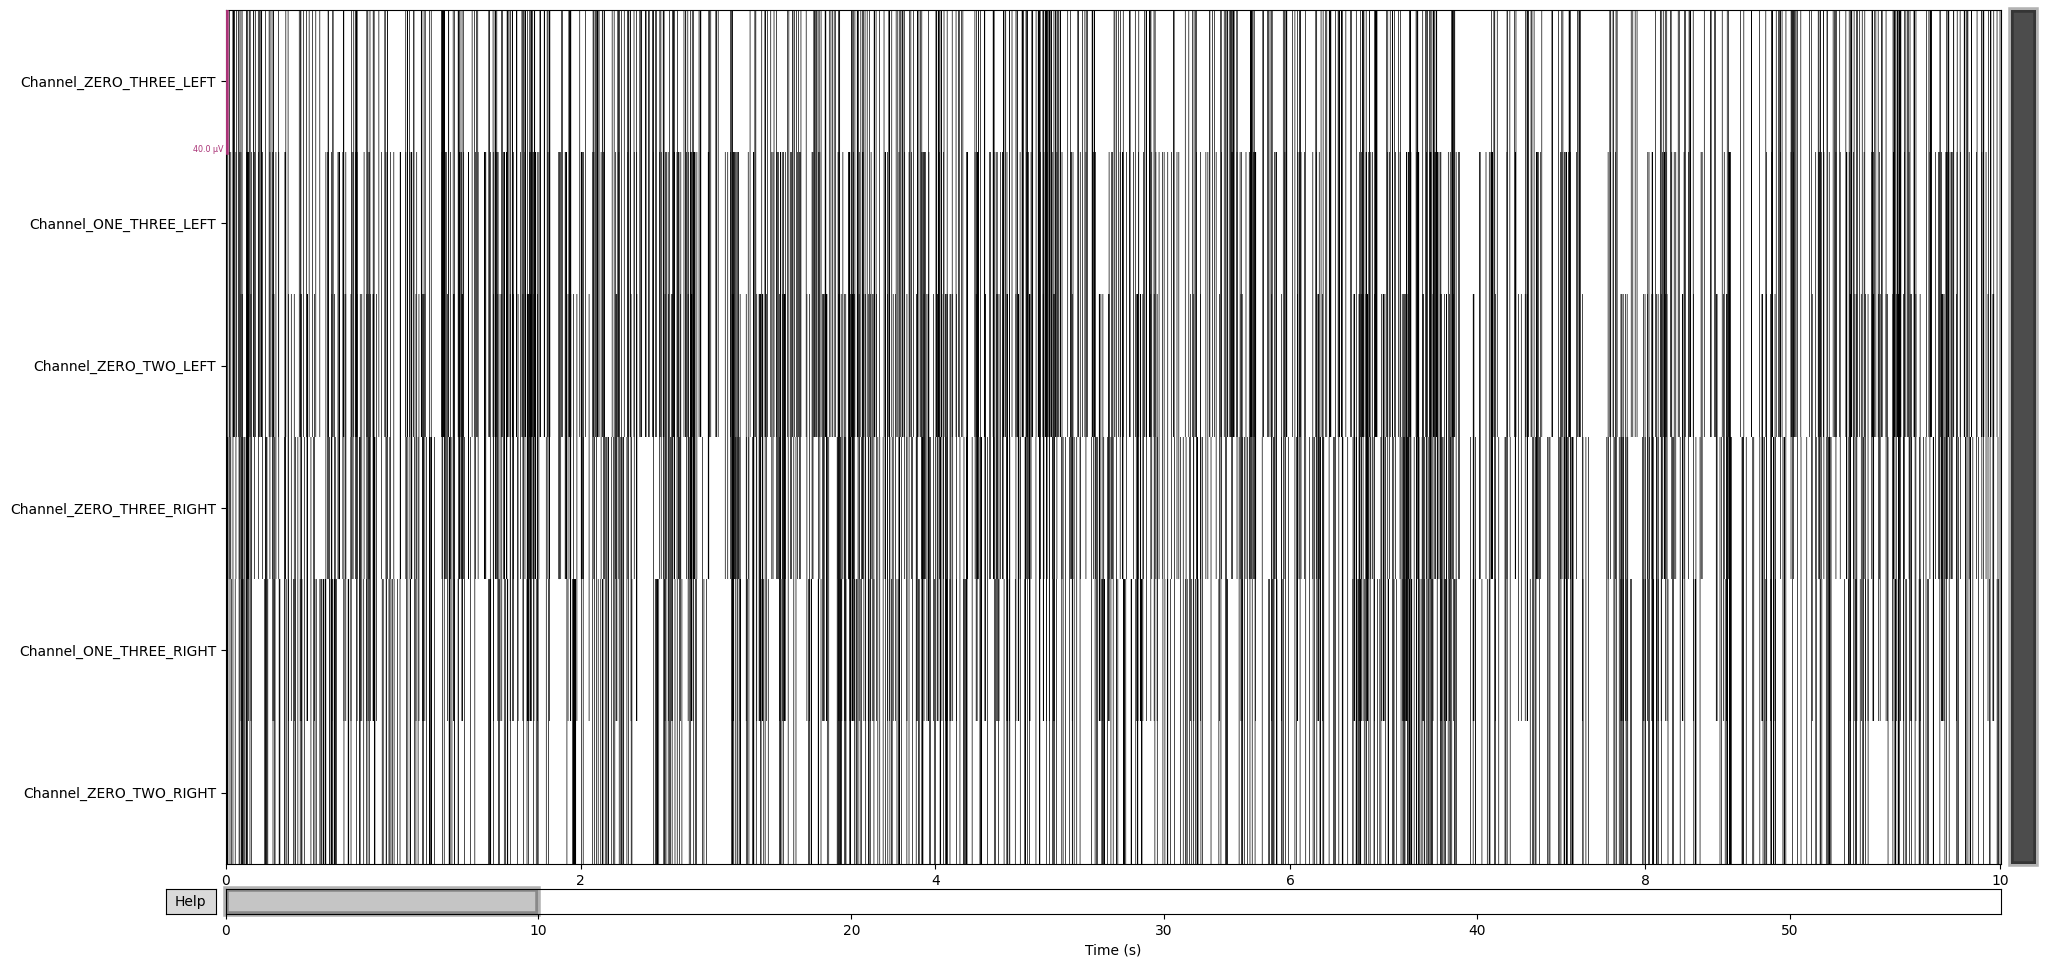

In [105]:
BrainSenseRawsCorrected['IS_1'].plot()

In [114]:
selected_streams = ['streaming_1', 'IS_1', 'streaming_2']

# Order the selected streams based on 'LFP Recording start' from streamings_df_corrected:
ordered_selected_streams = (
    streamings_df_corrected[
        streamings_df_corrected["Streaming id"].isin(selected_streams)
    ]
    .sort_values("LFP Recording start")["Streaming id"]
    .tolist()
)

ordered_selected_streams

['IS_1', 'streaming_1', 'streaming_2']

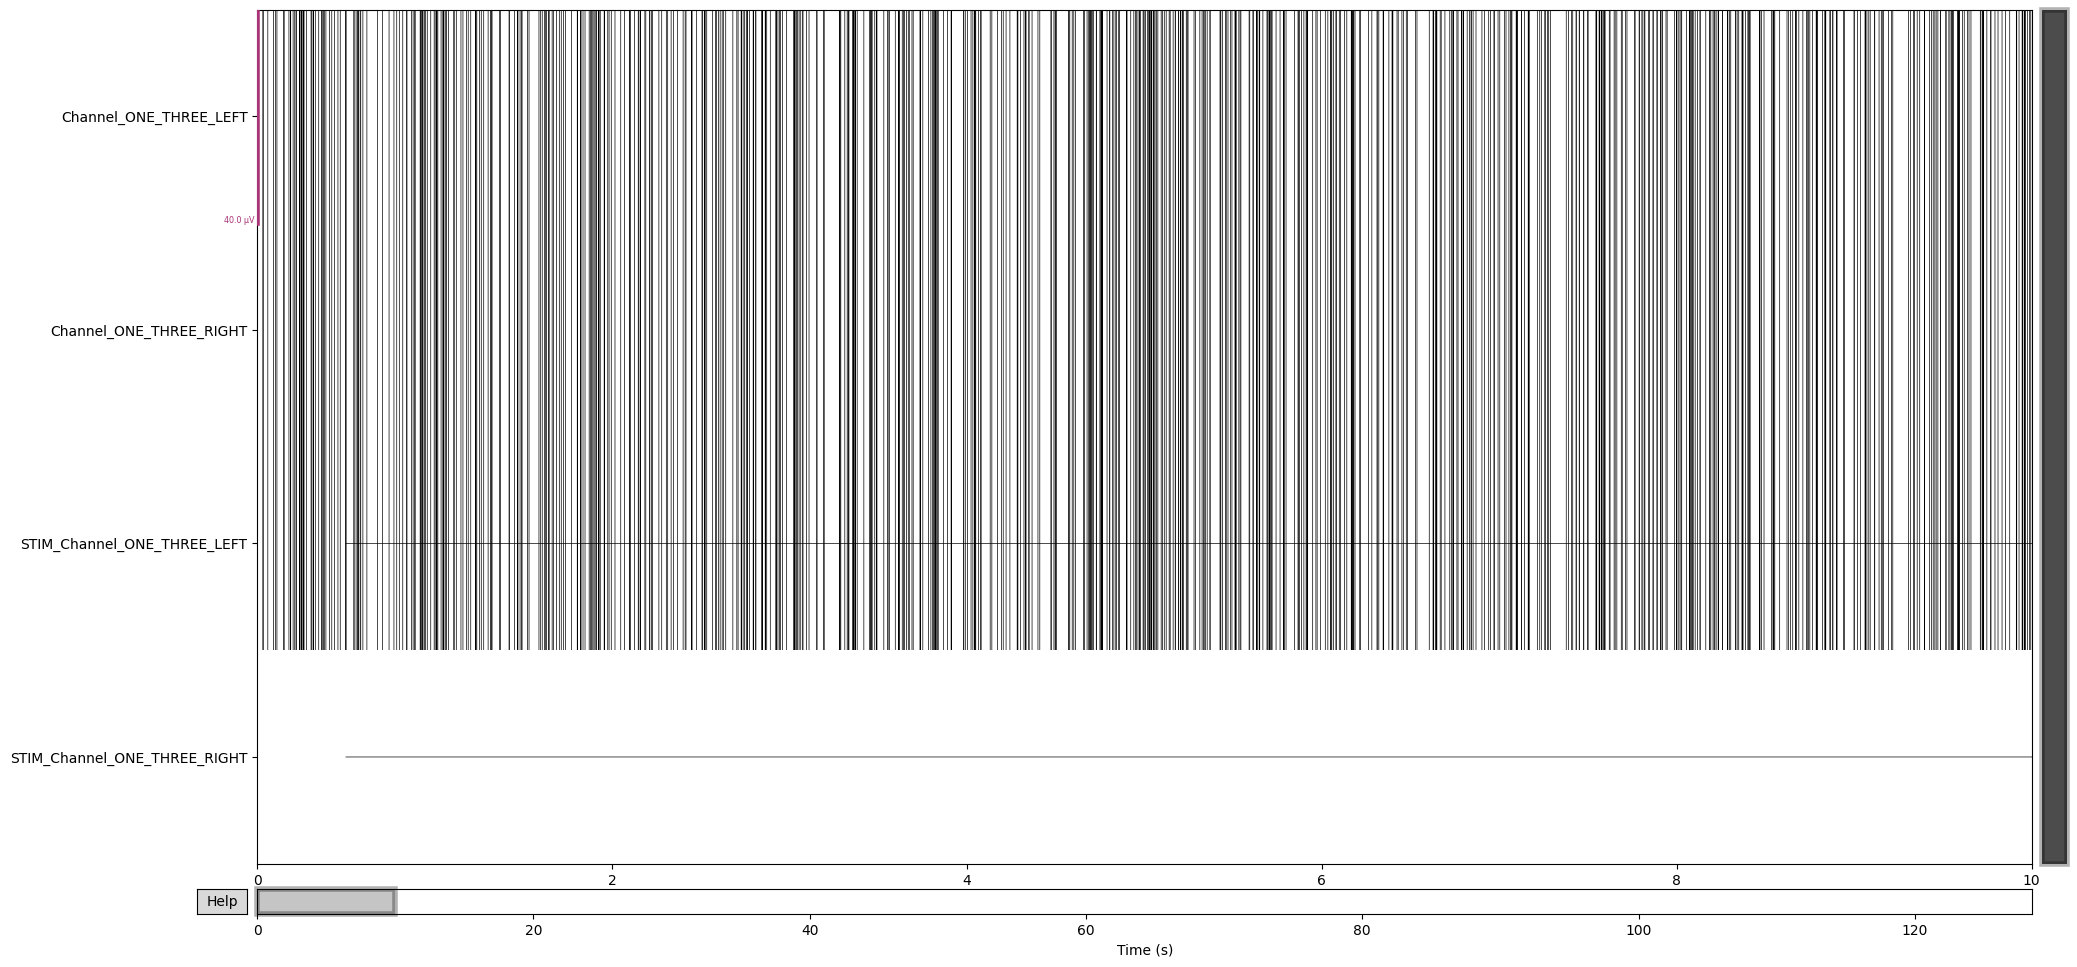

Channels marked as bad:
none


In [115]:
BrainSenseRawsCorrected['streaming_1'].plot()

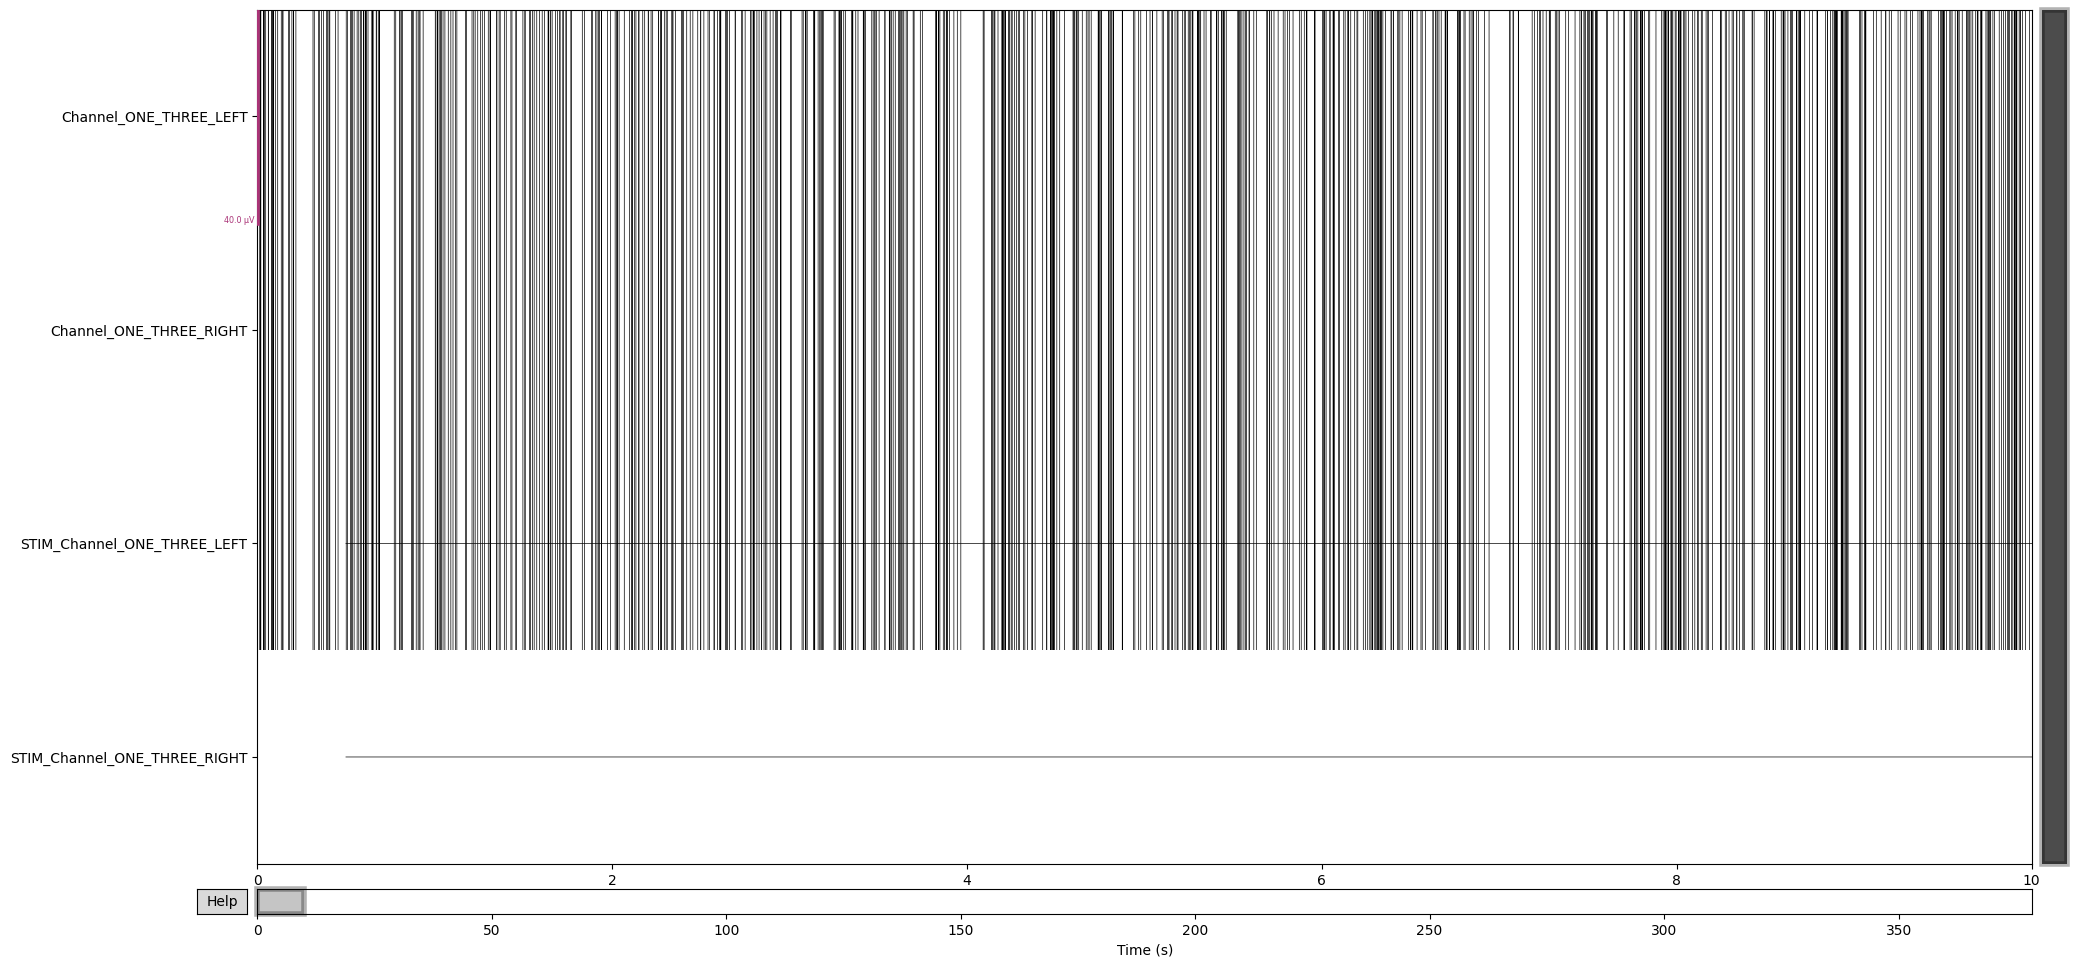

Channels marked as bad:
none


In [116]:
BrainSenseRawsCorrected['streaming_2'].plot()

In [117]:
# Filter BrainSenseRaws based on user selection
BrainSenseRawsCorrected = {k: v for k, v in BrainSenseRawsCorrected.items() if k in ordered_selected_streams}

# Check how many streams were selected
if len(ordered_selected_streams) > 1:
    print(f"Multiple streams selected: {ordered_selected_streams}. They will be concatenated with NaNs for the time gaps.")
    # calculate diff between end time of each stream and start time of next stream
    for i in range(len(ordered_selected_streams) - 1):
        stream_type_next = 'IS' if 'IS' in ordered_selected_streams[i + 1] else 'BS'
        stream_type_current = 'IS' if 'IS' in ordered_selected_streams[i] else 'BS'
        end_time_current = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == ordered_selected_streams[i], 
            'Last packet time (ms)'
            ].values[0]
        start_time_next = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == ordered_selected_streams[i + 1], 
            'First packet time (ms)'
            ].values[0]
        if stream_type_next == 'IS': # first packet of IS stream is not 250ms long, it only contains 38 samples, so we only need to subtract 38*4ms = 152ms from the start time of the next stream to get the actual time gap
            diff = (start_time_next - 152) - end_time_current
        else:    
            diff = (start_time_next - 250) - end_time_current
        # check if there was a clock reset (i.e., negative diff)
        if diff < 0:
            print(f'A clock reset was detected between {ordered_selected_streams[i]} and {ordered_selected_streams[i + 1]}. Adding 3276800ms to the next stream timestamps.')
            start_time_next += 3276800
            # recalculate diff
            if stream_type_next == 'IS': # first packet of IS stream is not 250ms long, it only contains 38 samples, so we only need to subtract 38*4ms = 152ms from the start time of the next stream to get the actual time gap
                diff = (start_time_next - 152) - end_time_current
            else:    
                diff = (start_time_next - 250) - end_time_current
        print(f'Time gap between {ordered_selected_streams[i]} and {ordered_selected_streams[i + 1]}: {diff} ms')

        # # check that duration of second stream matches number of samples
        # # sometimes, packets have an irregular size, leading to a mismatch between expected duration and actual number of samples
        # # check if first packet sizes is always either 62 or 63 samples to get real start time
        # packet_sizes = streamings_dict[ordered_selected_streams[i + 1]][list(streamings_dict[ordered_selected_streams[i + 1]].keys())[0]]['GlobalPacketSizes']
        # # get sizes that are not 62 or 63
        # if packet_sizes[0] not in [62, 63]:
        #     diff -= (packet_sizes[0] - 62) * 4  # each sample is 4ms at 250Hz

        # Concatenate the selected streams by adding NaNs for the time gap
        first_temp = BrainSenseRawsCorrected[ordered_selected_streams[i]].get_data()     
        second_temp = BrainSenseRawsCorrected[ordered_selected_streams[i + 1]].get_data()
        n_missing_samples = int(diff / 4)  # since sampling rate is 250Hz, each sample is 4ms

        # check number of channels in first_temp and second_temp, if they are different, add NaNs to the one with fewer channels
        if first_temp.shape[0] < second_temp.shape[0]:
            n_channels_to_add = second_temp.shape[0] - first_temp.shape[0]
            nan_padding_channels = np.full((n_channels_to_add, first_temp.shape[1]), np.nan)
            first_temp = np.concatenate((first_temp, nan_padding_channels), axis=0)
        if second_temp.shape[0] < first_temp.shape[0]:
            n_channels_to_add = first_temp.shape[0] - second_temp.shape[0]
            nan_padding_channels = np.full((n_channels_to_add, second_temp.shape[1]), np.nan)
            second_temp = np.concatenate((second_temp, nan_padding_channels), axis=0)    
        n_channels = first_temp.shape[0]
        nan_padding = np.full((n_channels, n_missing_samples), np.nan)
        concatenated_data = np.concatenate((first_temp, nan_padding, second_temp), axis=1)
        # info = ISRaws[ordered_selected_streams[i]].info
        # get the channel names from the IS, channel names are always the same I think?
        # if 'IS' in ordered_selected_streams[i]:
        #     ch_names = BrainSenseRawsCorrected[ordered_selected_streams[i]].info['ch_names']
        # elif 'IS' in ordered_selected_streams[i + 1]:
        #     ch_names = BrainSenseRawsCorrected[ordered_selected_streams[i + 1]].info['ch_names']  
        # else:
        #     print(f"Warning: No IS stream found in {ordered_selected_streams[i]} or {ordered_selected_streams[i + 1]}.")      
        ch_names = ['Channel_ZERO_THREE_LEFT',
            'Channel_ONE_THREE_LEFT',
            'Channel_ZERO_TWO_LEFT',
            'Channel_ZERO_THREE_RIGHT',
            'Channel_ONE_THREE_RIGHT',
            'Channel_ZERO_TWO_RIGHT']
        info = mne.create_info(
            ch_names=ch_names,
            sfreq=250,
            ch_types=['eeg'] * n_channels
        )
        BrainSenseRawsCorrected[ordered_selected_streams[i + 1]] = mne.io.RawArray(concatenated_data, info)
    # After concatenation, keep only the last stream as it contains all data
    selected_stream_id = ordered_selected_streams[-1]
else:
    selected_stream_id = ordered_selected_streams[0]

Multiple streams selected: ['IS_1', 'streaming_1', 'streaming_2']. They will be concatenated with NaNs for the time gaps.
Time gap between IS_1 and streaming_1: 90500.0 ms
Creating RawArray with float64 data, n_channels=6, n_times=68938
    Range : 0 ... 68937 =      0.000 ...   275.748 secs
Ready.


Time gap between streaming_1 and streaming_2: 18500.0 ms
Creating RawArray with float64 data, n_channels=6, n_times=168188
    Range : 0 ... 168187 =      0.000 ...   672.748 secs
Ready.


In [118]:
selected_stream_id

'streaming_2'

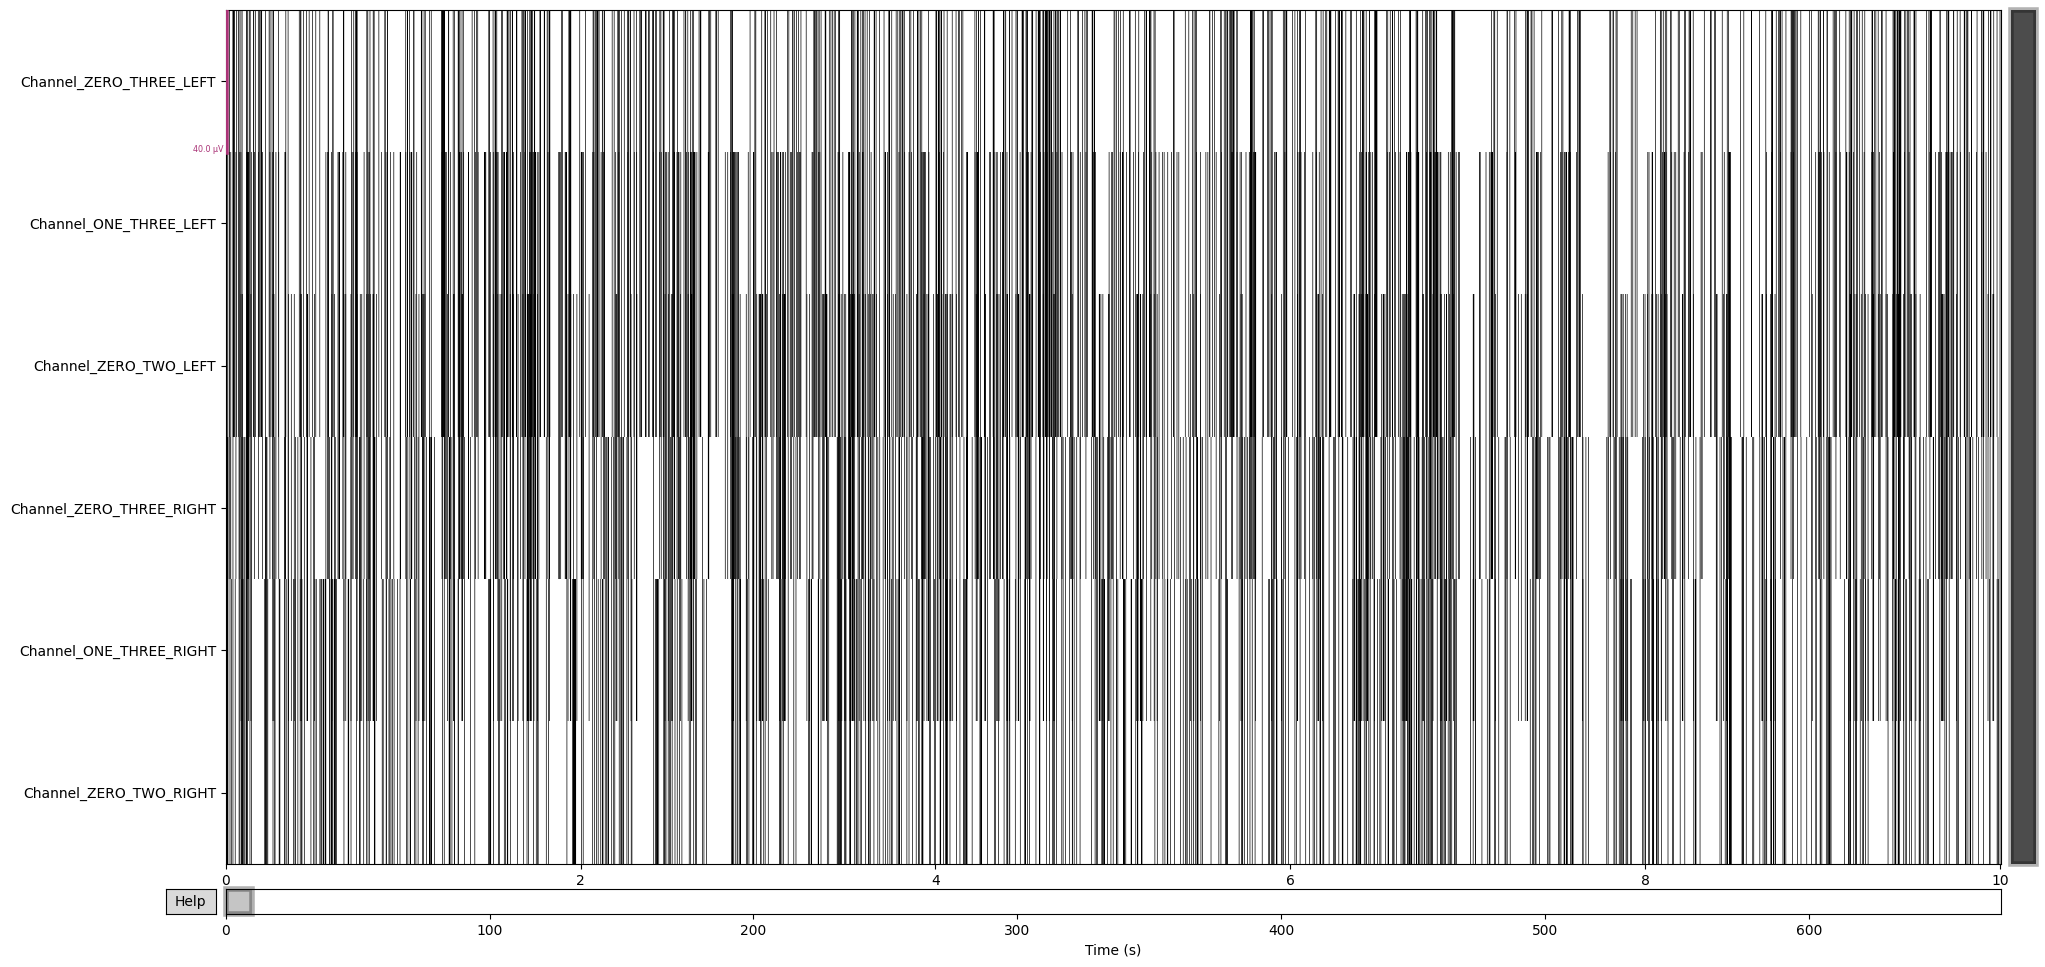

c:\Users\Juliette\anaconda3\envs\resync_test_env\lib\site-packages\mne\viz\_figure.py:379: RuntimeWarning: Mean of empty slice
  data -= np.nanmean(data, axis=1, keepdims=True)


Channels marked as bad:
[np.str_('Channel_ZERO_THREE_LEFT')]


In [119]:
BrainSenseRawsCorrected[selected_stream_id].plot()

In [81]:
BrainSenseRawsCorrected.keys()

dict_keys(['streaming_1', 'streaming_2'])

In [82]:
ISRaws.keys()

dict_keys(['IS_1', 'IS_2'])

In [ ]:
selected_streams = self.show_stream_selection_dialog(streamings_df_corrected)
if not selected_streams:
    QMessageBox.warning(self, "No Selection", "No stream was selected.")
    returns

# Filter BrainSenseRaws based on user selection
BrainSenseRawsCorrected = {k: v for k, v in BrainSenseRawsCorrected.items() if k in selected_streams}

# Check how many streams were selected
if len(selected_streams) > 1:
    QMessageBox.warning(
        self, "Multiple Streams Selected", 
        f"{len(selected_streams)} streams were selected and will be concatenated. \n"
        f"The following streams will be concatenated: {', '.join(selected_streams)}"
        )
    # calculate diff between end time of each stream and start time of next stream
    for i in range(len(selected_streams) - 1):
        end_time_current = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == selected_streams[i], 
            'Last packet time (ms)'
            ].values[0]
        start_time_next = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == selected_streams[i + 1], 
            'First packet time (ms)'
            ].values[0]
        diff = (start_time_next - 250) - end_time_current
        # check if there was a clock reset (i.e., negative diff)
        if diff < 0:
            print(f'A clock reset was detected between {selected_streams[i]} and {selected_streams[i + 1]}. Adding 3276800ms to the next stream timestamps.')
            start_time_next += 3276800
            # recalculate diff
            diff = (start_time_next - 250) - end_time_current
        print(f'Time gap between {selected_streams[i]} and {selected_streams[i + 1]}: {diff} ms')

        # check that duration of second stream matches number of samples
        # sometimes, packets have an irregular size, leading to a mismatch between expected duration and actual number of samples
        # check if first packet sizes is always either 62 or 63 samples to get real start time
        packet_sizes = streamings_dict[selected_streams[i + 1]][list(streamings_dict[selected_streams[i + 1]].keys())[0]]['GlobalPacketSizes']
        # get sizes that are not 62 or 63
        if packet_sizes[0] not in [62, 63]:
            diff -= (packet_sizes[0] - 62) * 4  # each sample is 4ms at 250Hz
        # irregular_sizes = [size for size in packet_sizes[0] if size not in [62, 63]]
        # #for size that are not 62 or 63, calculate the difference
        # if irregular_sizes:
        #     # assume they should be 62, sum up the "extra samples"
        #     # when packets have more samples than 62/63, it means that the recording 
        #     # device actually sent more samples, which should be taken into account 
        #     # when adding NaN values for concatenation
        #     total_extra_size = sum([size - 62 for size in irregular_sizes]) 
        #     print(f'Irregular packet sizes detected in {selected_streams[i + 1]}.')
        #     diff -= total_extra_size * 4  # each sample is 4ms at 250Hz  # update diff accordingly

        # Concatenate the selected streams by adding NaNs for the time gap
        first_temp = BrainSenseRawsCorrected[selected_streams[i]].get_data()
        second_temp = BrainSenseRawsCorrected[selected_streams[i + 1]].get_data()
        n_missing_samples = int(diff / 4)  # since sampling rate is 250Hz, each sample is 4ms
        n_channels = first_temp.shape[0]
        nan_padding = np.full((n_channels, n_missing_samples), np.nan)
        concatenated_data = np.concatenate((first_temp, nan_padding, second_temp), axis=1)
        info = BrainSenseRawsCorrected[selected_streams[i]].info
        BrainSenseRawsCorrected[selected_streams[i + 1]] = mne.io.RawArray(concatenated_data, info)
    # After concatenation, keep only the last stream as it contains all data
    selected_stream_id = selected_streams[-1]
else:
    selected_stream_id = selected_streams[0]


In [99]:
selected_stream_id

'streaming_2'

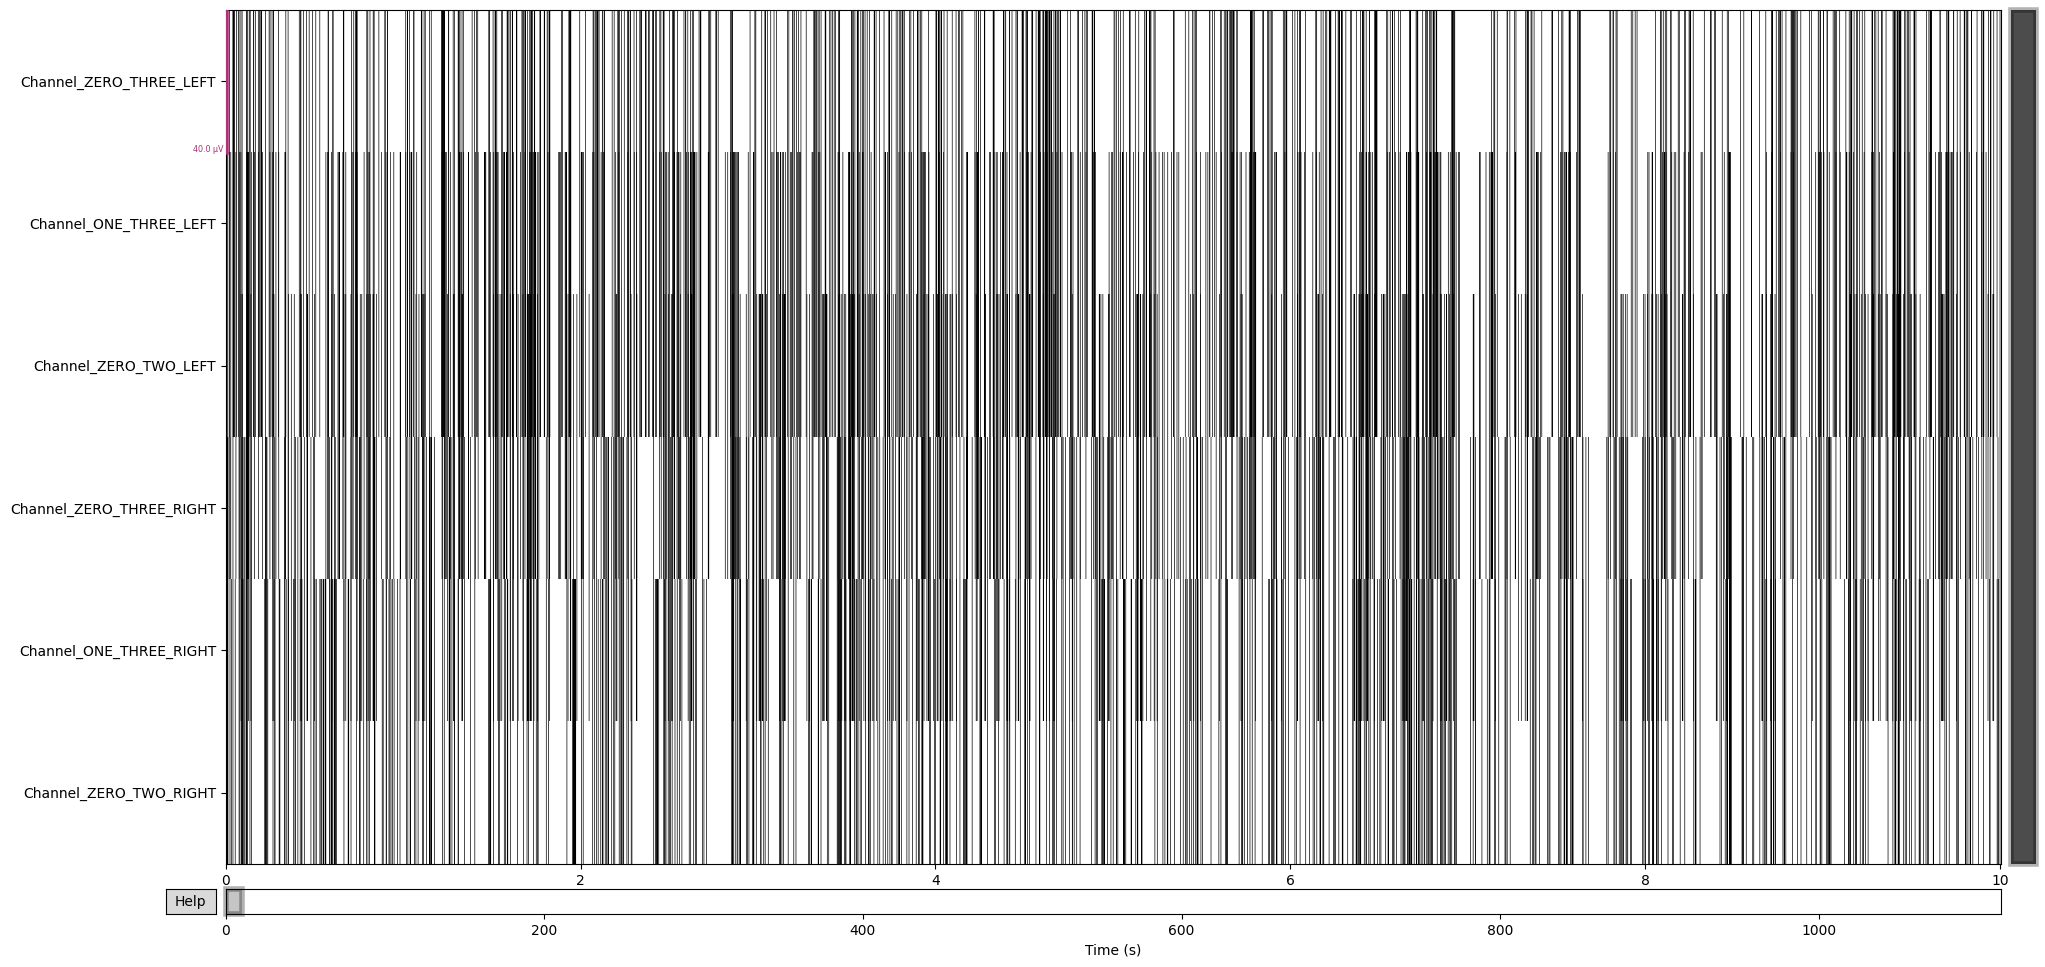

c:\Users\Juliette\anaconda3\envs\resync_test_env\lib\site-packages\mne\viz\_figure.py:379: RuntimeWarning: Mean of empty slice
  data -= np.nanmean(data, axis=1, keepdims=True)


In [101]:
BrainSenseRawsCorrected[selected_stream_id].plot()

In [ ]:
with open(file_name, 'r') as f:
    j = json.loads(f.read())        

list_of_streamings = j['BrainSenseTimeDomain']
list_of_stim_streamings = j['BrainSenseLfp']

streamings_dict = defaultdict(lambda: defaultdict(dict))
    
stream_times = [0]
first_packet_time = None
stream_count = 1

for i_stream, dat in enumerate(list_of_streamings):
    print(f"Stream {i_stream} keys: {dat.keys()}")  # DEBUG
    first_packet_time = dat['FirstPacketDateTime']

    if first_packet_time != stream_times[-1] or i_stream == 0:
        # new stream
        streamings_dict[f'streaming_{stream_count}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': first_packet_time,
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'], 
            'SampleRateInHz': dat['SampleRateInHz']
        }
        stream_count += 1
    else:
        # other channel from same stream
        streamings_dict[f'streaming_{stream_count - 1}'][f'Channel_{dat["Channel"]}'] = {
            'FirstPacketDateTime': dat['FirstPacketDateTime'],
            'GlobalSequences': functions.utils.convert_list_string_floats(dat['GlobalSequences']),
            'TicksInMses': functions.utils.convert_list_string_floats(dat['TicksInMses']),
            'GlobalPacketSizes': functions.utils.convert_list_string_floats(dat['GlobalPacketSizes']),
            'TimeDomainData': dat['TimeDomainData'],
            'SampleRateInHz': dat['SampleRateInHz']
        }
    stream_times.append(first_packet_time)

#  create a dataframe with all streamings and their channels
ends = []
prev_streaming_id = None
stream_count = -1
#prev_stream_last_stim_ticks = None

streamings_df = pd.DataFrame(columns=[
    'Streaming id', 'LFP Channels', 'LFP Recording start', 'LFP Recording end', 
    'LFP Recording duration'
    ])
for streaming_id in streamings_dict.keys():
    stream_count += 1
    channels = []
    time_since_last_rec_first_packet = None
    time_since_last_rec_ticks = None
    for channel in streamings_dict[streaming_id].keys():
        channels.append(channel)

        ticks_in_ms = streamings_dict[streaming_id][channel]['TicksInMses']
        rec_dur_ms = ticks_in_ms[-1] - ticks_in_ms[0] + 250  # add 250 ms for last packet duration
        rec_dur_min, rec_dur_sec, rec_dur_msec = functions.utils.convert_msec_to_min_sec_msec(rec_dur_ms)
        dt_str = streamings_dict[streaming_id][channel]['FirstPacketDateTime']
        dt_obj = datetime.strptime(dt_str, '%Y-%m-%dT%H:%M:%S.%fZ')
        
        # compute rec_end_time using dt_obj + rec_duration: 
        rec_end_time = dt_obj +  timedelta(minutes=rec_dur_min, seconds=rec_dur_sec, milliseconds=rec_dur_msec)

        if ends and streaming_id == prev_streaming_id:
            time_since_last_rec = timedelta(0)
        elif ends:
            time_since_last_rec = dt_obj - ends[-1]
        else:
            time_since_last_rec = timedelta(0)

        dt1_parsed = datetime.strptime(streamings_dict[streaming_id][channel]['FirstPacketDateTime'], "%Y-%m-%dT%H:%M:%S.%fZ")
        
        # Simply output it in the same visual format as dt2
        dt1_reformatted = dt1_parsed.strftime("%Y-%m-%d %H:%M:%S.%f")[:-3]  # trim to .XXX milliseconds
        
        if time_since_last_rec_first_packet is None:
            time_since_last_rec_first_packet = functions.utils.format_timedelta(time_since_last_rec)
        if time_since_last_rec_ticks is None:
            if streaming_id != 'streaming_1':  # for the first streaming, we don't have a previous streaming to compare to
                channel_previous = list(streamings_dict[prev_streaming_id].keys())[0]
            else:
                channel_previous = channel    
            time_since_last_rec_ticks = functions.utils.format_timedelta(timedelta(milliseconds=(ticks_in_ms[0] - (streamings_dict[prev_streaming_id][channel_previous]['TicksInMses'][-1])) )) if ends and streaming_id != prev_streaming_id else '0 days, 0h, 0min, 0s, 0ms'
        prev_streaming_id = streaming_id
        # convert time_since_last_rec in milliseconds
        #time_since_last_rec_ticks_ms = functions.utils.time_to_ms(time_since_last_rec_ticks)
        #time_since_last_rec_first_packet_ms = functions.utils.time_to_ms(time_since_last_rec_first_packet)

        ends.append(rec_end_time)

    data = list_of_stim_streamings[stream_count]['LfpData']
    #ticks = np.array([d['TicksInMs'] for d in data])
    right_mA = np.array([d['Right']['mA'] for d in data])
    left_mA = np.array([d['Left']['mA'] for d in data])
    #time_since_last_rec_ticks_stim = (ticks[0] - 250) - prev_stream_last_stim_ticks if prev_stream_last_stim_ticks is not None else 0
    #prev_stream_last_stim_ticks = ticks[-1] 
    new_row = pd.DataFrame([{
    'Streaming id': streaming_id,
    'LFP Channels': channels,
    'LFP Recording start': dt1_reformatted,
    'LFP Recording end': rec_end_time,
    'LFP Recording duration': f'{rec_dur_min} min, {rec_dur_sec} sec, {rec_dur_msec} ms',
    'First packet time (ms)': ticks_in_ms[0],
    'Last packet time (ms)': ticks_in_ms[-1],
    }])
    streamings_df = pd.concat([streamings_df, new_row], ignore_index=True)

BrainSenseRaws = {}

for i, stream in enumerate(streamings_dict.keys()):
    #stream_dict = {}
    ch_names = []
    stim_ch_names = []
    data_arrays = []
    raw = streamings_dict[stream]
    for ch in raw.keys(): 
        ch_data = raw[ch]['TimeDomainData']
        ch_names.append(ch)
        #data_arrays.append(ch_data)
        data_arrays.append(np.array(ch_data)) #* 1e-6)
        #side = 'Left' if 'LEFT' in ch else 'Right'
        stim_ch_names.append('STIM_' + ch)

# Because their sampling rate is different, resample them so that they match the LFP data length and crop if necessary (for small irregularities)        
    stim_sf = j['BrainSenseLfp'][i]['SampleRateInHz']  # == 2Hz
    left_stim = []
    right_stim = []
    for k in range(len(j['BrainSenseLfp'][i]['LfpData'])):
        # get right and left mA values
        right_mA = j['BrainSenseLfp'][i]['LfpData'][k]['Right']['mA']
        left_mA = j['BrainSenseLfp'][i]['LfpData'][k]['Left']['mA']
        right_stim.append(right_mA)
        left_stim.append(left_mA)        
    nb_points_stim = len(right_stim)
    stim_time = np.arange(nb_points_stim) * (1.0 / stim_sf)      # e.g. every 0.5 s          
    lfp_time  = np.arange(int(len(right_stim) * (250 / stim_sf))) / 250  # upsampled time

    # resample stim data to match lfp data length
    # Nearest-neighbor interpolation
    right_stim_resampled = np.interp(
        lfp_time,
        stim_time,
        right_stim,
        left=None,
        right=None,
    )

    left_stim_resampled = np.interp(
        lfp_time,
        stim_time,
        left_stim,
        left=None,
        right=None,
    )    

    # add some NaNs if resampled stim data is shorter than lfp data
    lfp_data_length = len(raw[ch]['TimeDomainData'])
    if len(left_stim_resampled) < lfp_data_length:
        left_stim_resampled = np.concatenate([np.nan * np.ones(lfp_data_length - len(left_stim_resampled)), left_stim_resampled])
    elif len(left_stim_resampled) > lfp_data_length:
        left_stim_resampled = left_stim_resampled[-lfp_data_length:]
    if len(right_stim_resampled) < lfp_data_length:
        right_stim_resampled = np.concatenate([np.nan * np.ones(lfp_data_length - len(right_stim_resampled)), right_stim_resampled])
    elif len(right_stim_resampled) > lfp_data_length:
        right_stim_resampled = right_stim_resampled[-lfp_data_length:]            
    left_stim_resampled_scaled = np.array(left_stim_resampled) #* 1e-6
    right_stim_resampled_scaled = np.array(right_stim_resampled) #* 1e-6
    # data_arrays.append(left_stim_resampled_scaled)
    # data_arrays.append(right_stim_resampled_scaled)
    # only keep stim channel is lfp channel present:
    if any("LEFT" in ch for ch in ch_names):
        data_arrays.append(left_stim_resampled_scaled)
    if any("RIGHT" in ch for ch in ch_names):
        data_arrays.append(right_stim_resampled_scaled)

    info = mne.create_info(
    ch_names=ch_names + stim_ch_names,
    sfreq=250,  # Percept sampling frequency is by default 250Hz
    ch_types=['eeg'] * len(ch_names) + ['eeg'] * len(stim_ch_names)
    )

    raw = mne.io.RawArray(
        data = np.array(data_arrays),
        info = info
    )
    BrainSenseRaws[stream] = raw                

# Now BrainSenseRaws contains all streams as MNE Raw objects, but we 
# still need to check for missing packets and correct them
# Loop through each stream and check for missing packets in each channel 
# based on the function check_and_correct_missing_packets()
BrainSenseRawsCorrected, streamings_df_corrected = functions.utils.check_and_correct_missing_packets(streamings_dict, BrainSenseRaws, streamings_df) 

# Create a pop-up window to show the data frame and let user select the stream they want to load
selected_streams = self.show_stream_selection_dialog(streamings_df_corrected)
if not selected_streams:
    QMessageBox.warning(self, "No Selection", "No stream was selected.")
    return

# Filter BrainSenseRaws based on user selection
BrainSenseRawsCorrected = {k: v for k, v in BrainSenseRawsCorrected.items() if k in selected_streams}

# Check how many streams were selected
if len(selected_streams) > 1:
    QMessageBox.warning(
        self, "Multiple Streams Selected", 
        f"{len(selected_streams)} streams were selected and will be concatenated. \n"
        f"The following streams will be concatenated: {', '.join(selected_streams)}"
        )
    # calculate diff between end time of each stream and start time of next stream
    for i in range(len(selected_streams) - 1):
        end_time_current = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == selected_streams[i], 
            'Last packet time (ms)'
            ].values[0]
        start_time_next = streamings_df_corrected.loc[
            streamings_df_corrected['Streaming id'] == selected_streams[i + 1], 
            'First packet time (ms)'
            ].values[0]
        diff = (start_time_next - 250) - end_time_current
        # check if there was a clock reset (i.e., negative diff)
        if diff < 0:
            print(f'A clock reset was detected between {selected_streams[i]} and {selected_streams[i + 1]}. Adding 3276800ms to the next stream timestamps.')
            start_time_next += 3276800
            # recalculate diff
            diff = (start_time_next - 250) - end_time_current
        print(f'Time gap between {selected_streams[i]} and {selected_streams[i + 1]}: {diff} ms')

        # check that duration of second stream matches number of samples
        # sometimes, packets have an irregular size, leading to a mismatch between expected duration and actual number of samples
        # check if first packet sizes is always either 62 or 63 samples to get real start time
        packet_sizes = streamings_dict[selected_streams[i + 1]][list(streamings_dict[selected_streams[i + 1]].keys())[0]]['GlobalPacketSizes']
        # get sizes that are not 62 or 63
        if packet_sizes[0] not in [62, 63]:
            diff -= (packet_sizes[0] - 62) * 4  # each sample is 4ms at 250Hz
        # irregular_sizes = [size for size in packet_sizes[0] if size not in [62, 63]]
        # #for size that are not 62 or 63, calculate the difference
        # if irregular_sizes:
        #     # assume they should be 62, sum up the "extra samples"
        #     # when packets have more samples than 62/63, it means that the recording 
        #     # device actually sent more samples, which should be taken into account 
        #     # when adding NaN values for concatenation
        #     total_extra_size = sum([size - 62 for size in irregular_sizes]) 
        #     print(f'Irregular packet sizes detected in {selected_streams[i + 1]}.')
        #     diff -= total_extra_size * 4  # each sample is 4ms at 250Hz  # update diff accordingly

        # Concatenate the selected streams by adding NaNs for the time gap
        first_temp = BrainSenseRawsCorrected[selected_streams[i]].get_data()
        second_temp = BrainSenseRawsCorrected[selected_streams[i + 1]].get_data()
        n_missing_samples = int(diff / 4)  # since sampling rate is 250Hz, each sample is 4ms
        n_channels = first_temp.shape[0]
        nan_padding = np.full((n_channels, n_missing_samples), np.nan)
        concatenated_data = np.concatenate((first_temp, nan_padding, second_temp), axis=1)
        info = BrainSenseRawsCorrected[selected_streams[i]].info
        BrainSenseRawsCorrected[selected_streams[i + 1]] = mne.io.RawArray(concatenated_data, info)
    # After concatenation, keep only the last stream as it contains all data
    selected_stream_id = selected_streams[-1]
else:
    selected_stream_id = selected_streams[0]

# Assign the corresponding MNE Raw object to dataset
self.dataset_intra.raw_data = BrainSenseRawsCorrected[selected_stream_id]

# Store related info
self.dataset_intra.sf = self.dataset_intra.raw_data.info['sfreq']
self.dataset_intra.ch_names = self.dataset_intra.raw_data.ch_names
nb_points = len(self.dataset_intra.raw_data.get_data()[0])
self.dataset_intra.times = np.arange(nb_points) * (1.0 / self.dataset_intra.sf)
self.dataset_intra.file_name = basename(file_name)
self.dataset_intra.file_path = dirname(file_name)    

# Update the GUI label
self.file_label_intra.setText(f"Selected File: {basename(file_name)} (Stream: {selected_stream_id})")
self.dataset_intra.selected_json_stream_name = selected_stream_id

# Enable plotting/select channel buttons
self.btn_select_channel_intra.setEnabled(True)
self.channel_label_intra.setEnabled(True)